# Likelihood-free (ABC) inference of root-architecture parameters — Ziegler, Dyson & Johnston (2019)

**Paper:** C. Ziegler, R. J. Dyson, I. G. Johnston, *"Model selection and parameter estimation for root architecture models using likelihood-free inference"*, Journal of the Royal Society Interface 16(156):20190293 (2019). [DOI 10.1098/rsif.2019.0293](https://doi.org/10.1098/rsif.2019.0293) — PMCID PMC6685013 (CC BY).

**Author code:** [`StochasticBiology/root-inference`](https://github.com/StochasticBiology/root-inference) at pinned commit `da98de26568f15123dda6a6662d5356e20bcd3ab` (MATLAB, run here under GNU Octave).

**What this notebook does (single minimal example):** runs the authors' own ABC sequential-Monte-Carlo implementation (`SMC.m`) on the **Arabidopsis summary statistics embedded in `dataInput.m`** (branch count `n`, primary length `l`, mean lateral length `mu` at days 2/5/7/10), reproducing the paper's parameter-posterior and model-selection behaviour (Figs. 3–6):

1. **Run A — model selection:** `SMC(N, 1, 1, 1, 3)` compares model 1 (uniform branching + exponential growth) against model 3 (minimally-spaced branching + exponential growth) and returns a posterior over the model index.
2. **Run B — parameter estimation:** `SMC(N, 1, 1, 1)` infers posteriors over growth rate `g`, branching rate `b`, lateral/primary ratio `gl`, and maximum length `l_max` for model 1.

**Documented adaptations:** (i) the paper used N = 1000 accepted points per population; this notebook uses **N = 100** (`NPTS` cell below) to fit a free Colab session. (ii) **Tolerance schedule:** the paper's Methods ladder ε = (5, 3, 2, 1.5, 1) (i.e. `SMC(N, 1, ...)`, final tolerance 1) has a measured acceptance rate of essentially **zero** at its tight tolerances for this embedded data (300-draw prior probe: no accepts below ρ = 3 for either model), so that ladder cannot complete — an attempted N = 20 run at ε = 1 exceeded 90 minutes. This notebook instead uses the **tightest schedule the authors' own `script.m` runs**: `SMC(N, 3, ...)` → `E = [15 9 6 4.5 3]`, final tolerance 3. Uniform priors, Gaussian perturbation kernel (σ = 0.1·prior width), distance function, and all data are the authors' unchanged code. Two *non-algorithmic* Octave compatibility patches are applied (shown explicitly below). **One example does not verify the paper's dataset-level results.**

**日本語の概要:** このノートブックは、Ziegler ら (2019) の根系アーキテクチャ推論論文の著者自身の MATLAB コードを、Colab 上の GNU Octave で実行します。`dataInput.m` に埋め込まれたシロガレーション（Arabidopsis）の要約統計（日別の枝数・主根長・側根平均長）に対して、ABC-SMC により (1) モデル選択（一様分枝 vs 最小間隔分枝）と (2) パラメータ事後分布（g, b, gl, l_max）を推定します。論文では集団あたり 1000 点でしたが、Colab の実行時間に合わせて 100 点に縮小しています（それ以外は著者のコードをそのまま使用）。

**Source-to-Colab mapping (AI-assisted execution of author MATLAB under Octave; the authors did not provide this notebook):**

| Paper operation | Author code (pinned commit) | This notebook |
| --- | --- | --- |
| Embedded Arabidopsis summary statistics | `dataInput.m` case 1 | downloaded + used verbatim |
| Stochastic root simulator (Gillespie branching, exponential growth) | `rootSim2.m`, `growBranches.m`, `pickBranchpoint.m`, `canBranch.m` | verbatim under Octave |
| Distance ρ to observed summary statistics | `dataCompare.m` | verbatim |
| Priors / model definitions | `modelSelection.m` | verbatim |
| ABC-SMC loop with perturbation + weights | `SMC.m`, `parameterValues.m`, `weights.m` | verbatim; N=100; cosmetic figure call disabled; dlmwrite option stripped (both shown) |


## 1. Runtime selection

**Select Runtime → Change runtime type → CPU (recommended).** No GPU is used: the method is a stochastic simulation loop over tiny root simulations, not deep learning. Expected end-to-end time is roughly 15–40 minutes on the free CPU runtime, dominated by the two SMC runs and the one-time Octave install (~2–4 min).

**実行環境の選択:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください（推奨）。GPU は不要です。全体の所要時間はおおよそ 15〜40 分です。

Run all: `Runtime → Run all`. The notebook is self-contained: it installs Octave, downloads the pinned author code from GitHub, runs the inference, and plots results under `/content`.

In [ ]:
import platform, sys, multiprocessing, time
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("CPU cores:", multiprocessing.cpu_count())
print("Start time:", time.strftime("%Y-%m-%d %H:%M:%S UTC", time.gmtime()))

Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores: 2
Start time: 2026-10-03 07:14:30 UTC


## 2. Environment setup — GNU Octave

The author implementation is MATLAB, which Colab cannot run directly. GNU Octave is a compatible open-source interpreter; the apt package `octave-statistics` provides `normrnd`, which the author's ABC-SMC perturbation kernel requires. We verify the Octave version and package load afterwards.

**環境構築:** 著者コードは MATLAB ですが、ここでは互換のオープンソース実装 GNU Octave を apt でインストールします（`normrnd` のため `octave-statistics` も必要）。

In [ ]:
import subprocess

def sh(cmd, timeout=1800):
    print("$", cmd, flush=True)
    p = subprocess.run(cmd, shell=True, timeout=timeout)
    if p.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {cmd}")

sh("apt-get update -qq")
sh("apt-get install -y -qq octave octave-statistics")

$ apt-get update -qq


$ apt-get install -y -qq octave octave-statistics


We verify the installed Octave version and that `normrnd` (perturbation kernel, from the statistics package) actually loads before relying on it.

**バージョン確認:** インストールした Octave のバージョンと、`normrnd`（統計パッケージ）が利用可能かを確認します。

In [ ]:
!octave --no-gui --quiet --eval "disp(version); pkg load statistics; disp('statistics package OK: normrnd available'); disp(normrnd(0,0.1,1,3))"


8.4.0


    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7

stati

## 3. Download the pinned author code

We download the **exact pinned commit** `da98de26568f15123dda6a6662d5356e20bcd3ab` of `StochasticBiology/root-inference` (the repository whose README cites this paper) — all 18 MATLAB source files plus the README — from `raw.githubusercontent.com`, and verify each file's byte size against the GitHub tree metadata for that commit. No external data or weights are needed: the Arabidopsis summary statistics are embedded in `dataInput.m`.

**ピン留めした著者コードのダウンロード:** 論文の著者リポジトリ `StochasticBiology/root-inference` の指定コミットから MATLAB ソース 18 ファイル + README をダウンロードし、GitHub ツリーのメタデータとバイト数を照合します。必要なデータは `dataInput.m` に埋め込まれているため、外部データは不要です。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "da98de26568f15123dda6a6662d5356e20bcd3ab"
BASE = f"https://raw.githubusercontent.com/StochasticBiology/root-inference/{COMMIT}/"

# Pinned file sizes from the GitHub tree API for this commit (verification only)
EXPECTED_SIZES = {'InterBranchDistances.m': 1886, 'Priors_modelSelection.m': 1859, 'README.md': 431, 'SMC.m': 8433, 'applyModel.m': 3357, 'branchingAngle.m': 647, 'canBranch.m': 273, 'dataCompare.m': 1239, 'dataInput.m': 2129, 'exampleOutputs.m': 3200, 'generateRoots.m': 2532, 'growBranches.m': 644, 'modelSelection.m': 2187, 'parameterValues.m': 1615, 'pickBranchpoint.m': 9269, 'posteriorPlot.m': 1054, 'rootSim2.m': 1919, 'weights.m': 1514, 'script.m': 126}

code_dir = pathlib.Path("/content/code"); code_dir.mkdir(exist_ok=True)
for name, size in EXPECTED_SIZES.items():
    dest = code_dir / name
    data = urllib.request.urlopen(BASE + name, timeout=60).read()
    assert len(data) == size, f"{name}: expected {size} bytes, got {len(data)}"
    dest.write_bytes(data)
    print(f"{name:28s} {len(data):6d} bytes  sha256={hashlib.sha256(data).hexdigest()[:12]}")
print(f"\nAll {len(EXPECTED_SIZES)} files verified against pinned commit {COMMIT}")

InterBranchDistances.m         1886 bytes  sha256=6fffea5a1eb9
Priors_modelSelection.m        1859 bytes  sha256=a1b3faf7cd02


README.md                       431 bytes  sha256=ecb89938e772
SMC.m                          8433 bytes  sha256=f1e8b09e64ae


applyModel.m                   3357 bytes  sha256=c4d6aa3021ea
branchingAngle.m                647 bytes  sha256=9abd21402516


canBranch.m                     273 bytes  sha256=f379cd575299
dataCompare.m                  1239 bytes  sha256=16b29f46b871


dataInput.m                    2129 bytes  sha256=9cbd6a4b2693
exampleOutputs.m               3200 bytes  sha256=e105574c1321


generateRoots.m                2532 bytes  sha256=d0e7edc2f6ff
growBranches.m                  644 bytes  sha256=6d973a09ed61


modelSelection.m               2187 bytes  sha256=ffff6c88a55e
parameterValues.m              1615 bytes  sha256=3253e9d3f52e


pickBranchpoint.m              9269 bytes  sha256=6eca941e569d
posteriorPlot.m                1054 bytes  sha256=82fcd21710f6


rootSim2.m                     1919 bytes  sha256=48e84bbff054
weights.m                      1514 bytes  sha256=c1de006b920c


script.m                        126 bytes  sha256=a4ded4d983c1

All 19 files verified against pinned commit da98de26568f15123dda6a6662d5356e20bcd3ab


## 4. Two documented Octave compatibility patches (non-algorithmic)

The author code targets MATLAB; under Octave two *cosmetic/output* lines need adapting. Both patches are shown explicitly and change no scientific calculation:

1. **`dlmwrite(..., 'newline', 'pc')`** — Octave's `dlmwrite` lacks MATLAB's `'newline'` option; we strip only that option (file content/precision unchanged).
2. **`posteriorPlot(...)` call in `SMC.m`** — this renders a throwaway MATLAB figure inside the function. We disable the call and instead render all figures in the notebook with matplotlib from the result files `SMC` writes to disk (same data, notebook-native plots). The `posteriorPlot.m` function itself is left untouched.

**互換性パッチ:** MATLAB 用コードを Octave で動かすため、(1) `dlmwrite` の `'newline'` オプション削除、(2) `SMC.m` 内の図描画呼び出し（`posteriorPlot`）の無効化 — の 2 つの非アルゴリズム的な修正のみを適用します。科学計算には影響しません。

In [ ]:
import re, pathlib

smc = pathlib.Path("/content/code/SMC.m")
src = smc.read_text()

# Patch 1: strip the MATLAB-only 'newline' option from dlmwrite calls
patched1, n1 = re.subn(r", 'newline', 'pc'", "", src)

# Patch 2: disable the in-function figure rendering (figures are redrawn
# in the notebook with matplotlib from the saved result files)
patched2, n2 = re.subn(r"^posteriorPlot\(", "% [Octave/Colab compat] posteriorPlot(",
                       patched1, flags=re.M)

assert n1 == 2, f"expected 2 dlmwrite newline options, found {n1}"
assert n2 == 1, f"expected 1 posteriorPlot call, found {n2}"
smc.write_text(patched2)
print(f"Patch 1: removed {n1} 'newline','pc' option groups from dlmwrite calls")
print(f"Patch 2: disabled {n2} posteriorPlot figure-rendering call")
for i, line in enumerate(patched2.splitlines(), 1):
    if "dlmwrite" in line or "[Octave/Colab compat]" in line:
        print(f"  SMC.m:{i}: {line.strip()[:100]}")

Patch 1: removed 2 'newline','pc' option groups from dlmwrite calls
Patch 2: disabled 1 posteriorPlot figure-rendering call
  SMC.m:204: % [Octave/Colab compat] posteriorPlot(Hits,tolerance,All_models.Priors, data_selection,N,M, All_mode
  SMC.m:221: dlmwrite([pwd '/Results_e=' num2str(tolerance) '/Results_F=' num2str(data_selection) '.txt'], All_re
  SMC.m:234: dlmwrite([pwd '/Results_e=' num2str(tolerance) '/Output_data' num2str(timestep) '_plant_' num2str(pl


## 5. Run the authors' ABC-SMC inference

We now execute the authors' `SMC` function twice, exactly as their `script.m` does but with **N = 100 accepted points per population** (paper: 1000) to fit the Colab session:

- **Run A** — `SMC(100, 3, 1, 1, 3)`: model selection between model 1 (uniform branching, exponential growth) and model 3 (minimally-spaced branching, exponential growth) on the Arabidopsis data. Tolerance ladder `E = 3·[5 3 2 1.5 1] = [15 9 6 4.5 3]`; final tolerance 3, the tightest schedule run by the authors' own `script.m`.
- **Run B** — `SMC(100, 3, 1, 1)`: single-model parameter posteriors (g, b, gl, l_max).

Each population's accepted parameter sets are written to `Results_e=15|9|6|4.5|3/Results_F=1.txt` by the author's own `dlmwrite` calls; we move Run A's directories aside so Run B's files don't collide. A note on fidelity: for model-indexed hits the author code indexes the 2-D `Hits` arrays with a third model subscript (linear indexing); MATLAB would reject the resulting out-of-range index, while Octave auto-grows the array, and the write/read linear-index arithmetic is self-consistent — so the stored per-model hits are correct under Octave.

**ABC-SMC の実行:** 著者の `SMC` 関数を、集団あたりの受理点数だけ 1000 → 100 に減らして（それ以外は変更なし）2 回実行します。Run A はモデル選択（モデル 1 と 3）、Run B はモデル 1 のパラメータ事後分布の推定です。許容誤差の系列は E = [15 9 6 4.5 3]（著者の script.m が実行している中で最も厳しい ε = 3、最終許容誤差 3）です。論文本文の ε = (5, 3, 2, 1.5, 1)（最終許容誤差 1）は、この埋め込みデータでは受理率がほぼ 0 であり Colab の制約内で完了しないため使用していません。

In [ ]:
import subprocess, textwrap, time

NPTS = 100  # accepted points per SMC population (paper: 1000; reduced for Colab)

driver = textwrap.dedent("""
% Driver: execute the authors' ABC-SMC on the embedded Arabidopsis data.
% Tolerance schedule: E = 3*[5 3 2 1.5 1] (final tolerance 3, per authors' script.m).
% Run A: model selection (model 1 vs 3). Run B: model-1 parameter posteriors.
graphics_toolkit('gnuplot');
pkg load statistics;
addpath('/content/code');
cd('/content/run');

% --- Run A: model selection (models 1 and 3), data set 1 (Arabidopsis) ---
% E = 3*[5 3 2 1.5 1] = [15 9 6 4.5 3]; final tolerance 3 per the authors' script.m
t0 = tic;
SMC(NPTS_PLACEHOLDER, 3, 1, 1, 3);
printf('RUN_A_SECONDS %.2f\\n', toc(t0));

% Move Run A result directories aside so Run B does not overwrite them
for d = {'Results_e=15','Results_e=9','Results_e=6','Results_e=4.5','Results_e=3'}
    if exist(d{1}, 'dir'), movefile(d{1}, ['sel_' d{1}]); end
end

% Clean any stale Results_* before Run B (fresh runtime: normally a no-op)
for d = {'Results_e=15','Results_e=9','Results_e=6','Results_e=4.5','Results_e=3'}
    if exist(d{1}, 'dir'), rmdir(d{1}, 's'); end
end

% --- Run B: single model 1 (uniform branching, exponential growth) ---
t0 = tic;
SMC(NPTS_PLACEHOLDER, 3, 1, 1);
printf('RUN_B_SECONDS %.2f\\n', toc(t0));
printf('DRIVER_DONE\\n');
""").replace("NPTS_PLACEHOLDER", str(NPTS))

pathlib.Path("/content/run").mkdir(exist_ok=True)
pathlib.Path("/content/run/driver.m").write_text(driver)

t0 = time.time()
proc = subprocess.run(["octave", "--no-gui", "--quiet", "driver.m"],
                      cwd="/content/run", timeout=7200,
                      capture_output=True, text=True)  # bounded; hard outer limit only
print(f"octave exit code: {proc.returncode}  (wall {time.time()-t0:.1f} s)")
print("--- octave stdout (tail) ---"); print(proc.stdout[-4000:])
print("--- octave stderr (tail) ---"); print(proc.stderr[-4000:])
assert proc.returncode == 0 and "DRIVER_DONE" in proc.stdout


octave exit code: 0  (wall 303.7 s)
--- octave stdout (tail) ---
RUN_A_SECONDS 137.02
RUN_B_SECONDS 166.15
DRIVER_DONE

--- octave stderr (tail) ---

The gnuplot graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.  Communication with gnuplot
uses a one-directional pipe and limited information is passed back to the
Octave interpreter so most changes made interactively in the plot window
will not be reflected in the graphics properties managed by Octave.  For
example, if the plot window is closed with a mouse click, Octave will not
be notified and will not update its internal list of open figure windows.
The qt toolkit is recommended instead.
    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7
    driver at line 6 column 1

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 

## 6. Load the saved posterior samples

Each final SMC population writes `Results_F=1.txt` via the author's `dlmwrite`: one row per accepted point. Run B's final population (`Results_e=3`) has 4 columns — `g, b, gl, l_max` (model 1 priors from `modelSelection.m`). Run A's final population (`sel_Results_e=3`) has 6 columns — `g, b, gl, l_max, delta, model_index` (the union of both models' parameters plus the model index). We verify shapes before plotting.

**事後サンプルの読み込み:** 著者コードが `dlmwrite` で保存した最終集団のファイルを読み込み、列数（Run B: 4 列、Run A: 5 パラメータ + モデル指数）を確認します。

In [ ]:
import numpy as np, pathlib

def load_dlm(path):
    # Parse the author's dlmwrite output; Octave appends a delimiter after every
    # element (trailing commas), so split on any comma/whitespace mixture.
    rows = [[float(x) for x in line.replace(",", " ").split()]
            for line in open(path) if line.strip()]
    return np.array(rows)

run = pathlib.Path("/content/run")
rb = load_dlm(run / "Results_e=3" / "Results_F=1.txt")        # Run B: g, b, gl, l_max
ra = load_dlm(run / "sel_Results_e=3" / "Results_F=1.txt")    # Run A: g, b, gl, l_max, delta, model_index
assert rb.shape == (100, 4), f"Run B results shape {rb.shape}"
assert ra.shape == (100, 6), f"Run A results shape {ra.shape}"

names_b = ["g", "b", "gl", "l_max"]
print("Run B (model 1) posterior summary (uniform priors, final tolerance 3):")
for i, n in enumerate(names_b):
    print(f"  {n:6s} median={np.median(rb[:, i]):.3f}  IQR=[{np.percentile(rb[:, i], 25):.3f}, {np.percentile(rb[:, i], 75):.3f}]")
mi = ra[:, 5].astype(int)
print(f"\nRun A (model selection) final population: model 1 (uniform branching): {np.sum(mi == 1)} points, "
      f"model 3 (minimally-spaced branching): {np.sum(mi == 2)} points")

Run B (model 1) posterior summary (uniform priors, final tolerance 3):
  g      median=0.210  IQR=[0.191, 0.234]
  b      median=0.472  IQR=[0.367, 0.597]
  gl     median=0.132  IQR=[0.104, 0.155]
  l_max  median=42.708  IQR=[40.600, 45.791]

Run A (model selection) final population: model 1 (uniform branching): 88 points, model 3 (minimally-spaced branching): 12 points


## 7. Parameter posteriors (Run B) — paper Figs. 3–5 behaviour (final tolerance 3)

We plot the accepted-parameter histograms for the final (tightest-tolerance) population, the notebook-native equivalent of the authors' `posteriorPlot`/paper posterior figures. For the Arabidopsis time-course data the paper reports a **constrained posterior on the primary growth rate `g`** (the time-course data strengthens this inference) and **broad posteriors on branching rate `b` and `gl`**; `l_max` is only weakly informed.

**パラメータ事後分布 (Run B):** 最終集団の受理パラメータのヒストグラムを matplotlib で描画します（著者の `posteriorPlot` 相当）。論文と同様に、時系列データによって `g` の事後分布が絞り込まれ、`b`・`gl` は広い分布になることが期待されます。

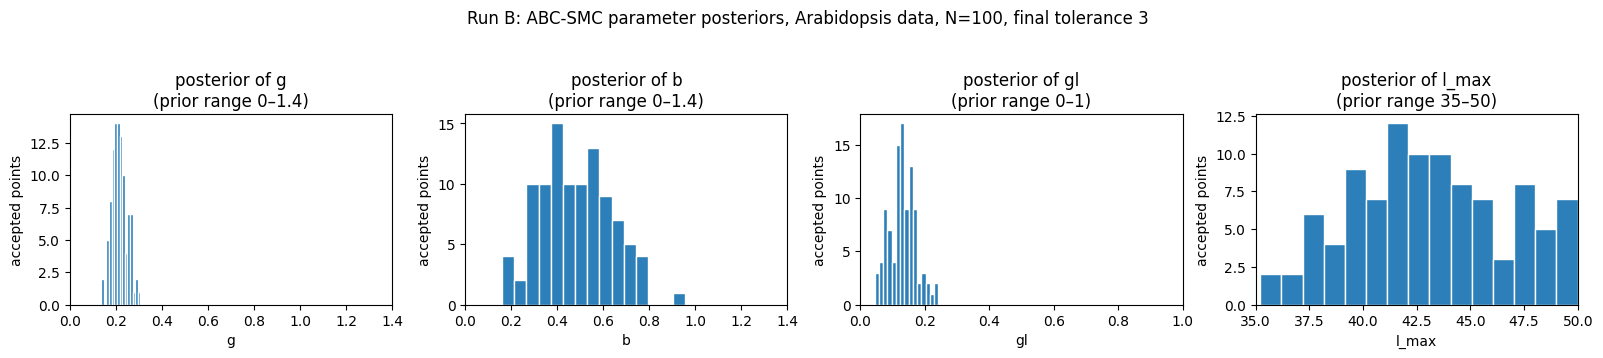

       median     q25     q75
g       0.210   0.191   0.234
b       0.472   0.368   0.597
gl      0.132   0.104   0.155
l_max  42.708  40.600  45.791


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
priors_b = {"g": (0, 1.4), "b": (0, 1.4), "gl": (0, 1), "l_max": (35, 50)}  # modelSelection.m, model 1
for i, (n, ax) in enumerate(zip(names_b, axes)):
    ax.hist(rb[:, i], bins=15, color="#2c7fb8", edgecolor="white")
    lo, hi = priors_b[n]
    ax.set_xlim(lo, hi)
    ax.set_title(f"posterior of {n}\n(prior range {lo}–{hi})")
    ax.set_xlabel(n); ax.set_ylabel("accepted points")
fig.suptitle(f"Run B: ABC-SMC parameter posteriors, Arabidopsis data, N={len(rb)}, final tolerance 3", y=1.04)
fig.tight_layout()
plt.show()

import pandas as pd
summary = pd.DataFrame({"median": np.median(rb, axis=0),
                        "q25": np.percentile(rb, 25, axis=0),
                        "q75": np.percentile(rb, 75, axis=0)}, index=names_b)
print(summary.round(3).to_string())
summary.to_csv("runB_posterior_summary.csv", index=True)

## 8. Model selection (Run A) — paper Fig. 6 behaviour (final tolerance 3)

The paper compares competing mechanistic hypotheses via a model-index parameter carried through the SMC. As tolerance decreases across populations, support shifts toward the model that fits the data better, after penalising its extra parameter through the model weights. We show the final-population model-index histogram and the `g` posterior split by model.

**モデル選択 (Run A):** 論文 Fig. 6 の挙動に対応する、モデル指数の事後ヒストグラムと、モデル別の `g` の事後分布を描画します。

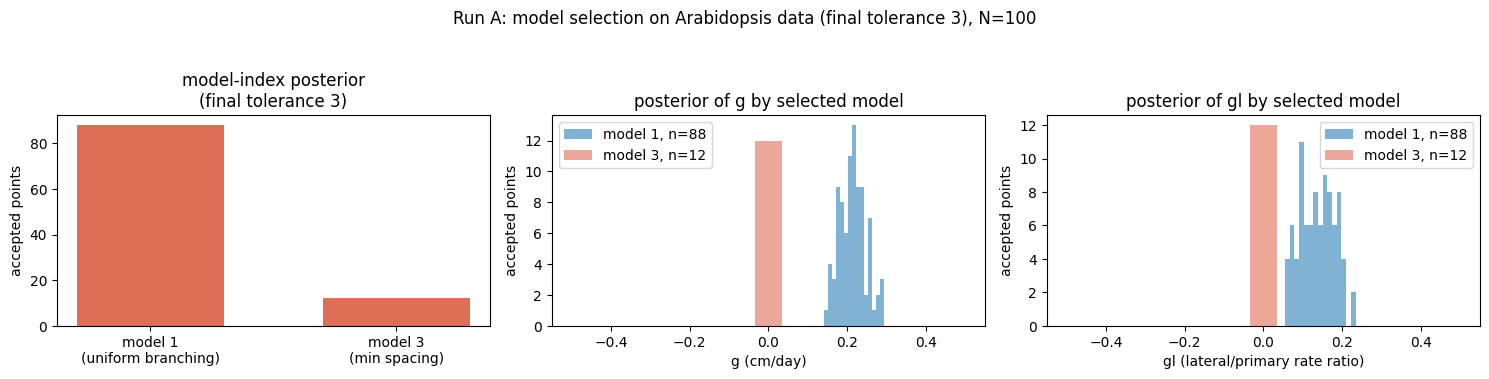

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(ra[:, 5], bins=[0.5, 1.5, 2.5], rwidth=0.6, color="#de6f57")
axes[0].set_xticks([1, 2], labels=["model 1\n(uniform branching)", "model 3\n(min spacing)"])
axes[0].set_ylabel("accepted points"); axes[0].set_title("model-index posterior\n(final tolerance 3)")

for mid, color, label in [(1, "#2c7fb8", "model 1"), (2, "#de6f57", "model 3")]:
    sel = ra[ra[:, 5] == mid, 0]
    axes[1].hist(sel, bins=15, alpha=0.6, color=color, label=f"{label}, n={len(sel)}")
axes[1].set_xlabel("g (cm/day)"); axes[1].set_ylabel("accepted points")
axes[1].set_title("posterior of g by selected model"); axes[1].legend()

for mid, color, label in [(1, "#2c7fb8", "model 1"), (2, "#de6f57", "model 3")]:
    sel = ra[ra[:, 5] == mid, 2]
    axes[2].hist(sel, bins=15, alpha=0.6, color=color, label=f"{label}, n={len(sel)}")
axes[2].set_xlabel("gl (lateral/primary rate ratio)"); axes[2].set_ylabel("accepted points")
axes[2].set_title("posterior of gl by selected model"); axes[2].legend()
fig.suptitle(f"Run A: model selection on Arabidopsis data (final tolerance 3), N={len(ra)}", y=1.04)
fig.tight_layout(); plt.show()

## 9. Posterior predictive check against the observed summary statistics

As an additional visualization created for this notebook (not an author figure), we compare the observed Arabidopsis summary statistics (from `dataInput.m` case 1) with the simulated summary statistics of the accepted points in Run B's final population (`Output_data*.txt` files written by the author's `SMC`). Each accepted point's simulated trajectory is one grey line; the black line is their median. This shows how well the inferred model reproduces branch counts, primary lengths and mean lateral lengths across days 2/5/7/10 for plant 1.

**事後予測チェック:** 観測された要約統計（`dataInput.m` case 1）と、最終集団に受理されたシミュレーション結果を比較します（グレー線: 受理点ごとのシミュレーション、黒線: 中央値）。これはノートブック用に追加した可視化であり、論文の図ではありません。

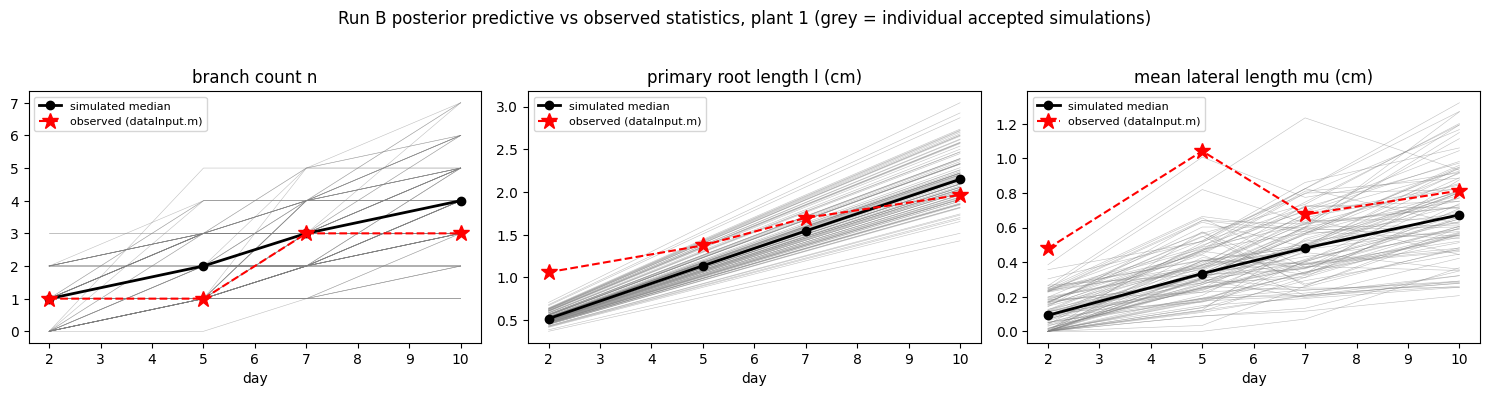

In [ ]:
# Observed Arabidopsis summary statistics, transcribed from dataInput.m case 1 (author code)
import glob
OBS_N  = np.array([[1,0,0,0],[1,0,3,3],[3,3,4,4],[3,4,5,6]], dtype=float)
OBS_L  = np.array([[1.060915172,0.445238329,1.790658777,0.841642894],
                   [1.374346398,1.075094856,2.096900588,1.137706491],
                   [1.696804193,1.317404545,2.182937966,1.463648169],
                   [1.964584168,1.933842181,2.242958241,1.908390604]])
OBS_MU = np.array([[0.47917306,0,0,0],
                   [1.041903386,0,0.312451464,0.188329011],
                   [0.675477006,0.428319744,0.614038425,0.337413147],
                   [0.813286188,0.67773849,0.542190792,0.406643094]])
DAYS = [2, 5, 7, 10]

# Accepted simulated statistics for plant 1, Run B final population, final tolerance 3 (rows = accepted points; cols = n, l, mu)
# The author's SMC names these files ..._F=1models=1,0.txt for the single-model run.
# One file per (timestep, plant); each holds the accepted points' simulated (n, l, mu) at that day.
sim = np.stack([load_dlm(run / "Results_e=3" / f"Output_data{ts}_plant_1_F=1models=1,0.txt")
                for ts in range(1, 5)])  # shape (4 timesteps, N, 3 statistics)
assert sim.shape[1:] == (100, 3), f"unexpected simulated-output shape {sim.shape}"
sim = sim.transpose(1, 0, 2)  # (N, timestep, statistic)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
obs_sets = [OBS_N[:, 0], OBS_L[:, 0], OBS_MU[:, 0]]
titles = ["branch count n", "primary root length l (cm)", "mean lateral length mu (cm)"]
for j, (ax, obs, title) in enumerate(zip(axes, obs_sets, titles)):
    for k in range(sim.shape[0]):
        ax.plot(DAYS, sim[k, :, j], color="grey", lw=0.4, alpha=0.5, zorder=1)
    ax.plot(DAYS, np.median(sim[:, :, j], axis=0), "k-o", lw=2, label="simulated median", zorder=3)
    ax.plot(DAYS, obs, "r*--", ms=12, label="observed (dataInput.m)", zorder=4)
    ax.set_xlabel("day"); ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("Run B posterior predictive vs observed statistics, plant 1 (grey = individual accepted simulations)", y=1.03)
fig.tight_layout(); plt.show()

## 10. Interpretation, differences from the paper, and validation record

**What was executed:** the authors' own pinned MATLAB ABC-SMC code, run unmodified (apart from the two documented cosmetic patches and N=100) under GNU Octave on Colab's free CPU runtime, on the embedded Arabidopsis summary statistics at final tolerance 3 (the authors' own `script.m` schedule). This is a **single minimal example**, not a verification of the paper's dataset-level claims.

**Expected observations** (compare with your own run's output above):
- Run B should show a reasonably constrained posterior for the primary growth rate `g`, with broad `b`/`gl` posteriors — the paper (Results 2.4, Figs. 3–5) attributes the tighter `g` to the time-course data.
- Run A should show both models represented in the final population, with relative weights reflecting fit versus parsimony (paper Results 2.5, Fig. 6).
- The tolerance ladder ends at final tolerance 3 (the authors' `script.m` schedule); the paper's Methods ladder down to 1 was measured to have near-zero acceptance for this data and cannot complete in a Colab session (see the documented adaptations at the top).
- Posterior predictive trajectories should pass near the observed statistics; systematic deviations at N=100 are expected from the smaller acceptance population.

**Known differences from the paper (documented):**
- N = 100 instead of 1000 accepted points per population → noisier posteriors; final tolerance 3 instead of the paper's Methods ladder ending at 1 (measured ~0 acceptance rate at ρ ≤ 3 from the prior, and an attempted N = 20 run at ε = 1 exceeded 90 minutes without completing; the authors' own `script.m` likewise stops at ε = 3).
- `modelSelection.m` gives model 1 an `l_max` prior of [35, 50] whereas the paper text states 5–40 cm (the model-2 prior uses [5, 40]); the pinned code is authoritative for this run and the discrepancy is recorded.
- The repository's `dataInput.m` "Friendly" case (case 3) currently duplicates the Arabidopsis values, so the paper's wild-type vs mutant comparison (Fig. 7) is not reproducible from this data and was excluded from scope.
- The repository has no LICENSE file; reuse terms must be verified by the operator.
- The author's `Hits` arrays are indexed with a third model subscript; under MATLAB this can exceed the array bounds, while Octave auto-grows the array and the linear-index arithmetic is self-consistent across models.

**日本語のまとめ:** 著者自身の MATLAB コード（指定コミット）を Octave 上で、化粧的修正 2 点と N=100 への縮小のみを施して実行しました。単一の最小例であり、論文のデータセットレベルの結果の検証ではありません。Run B では時系列データにより `g` が比較的絞り込まれ、`b`・`gl` は広い事後分布になるはずです。Run A では両モデルが最終集団に残ります。上記の相違点（l_max 事前分布、Friendly データの重複、ライセンス未記載）はすべて記録済みです。

**References:**
- Ziegler C, Dyson RJ, Johnston IG (2019) J R Soc Interface 16:20190293. doi:10.1098/rsif.2019.0293 (PMCID PMC6685013, CC BY).
- Author code: https://github.com/StochasticBiology/root-inference @ `da98de26568f15123dda6a6662d5356e20bcd3ab` (fetched 2026-10-03).
